In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import holidays
import seaborn as sns
# Check the GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# data loading

csv_path = 'D:/abc/data.csv' 
parquet_path = 'train-00000-of-00001.parquet'  

# Load from CSV first.
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path, parse_dates=['timestamp'])
    print(f"Loading data from CSV, shape:{df.shape}")
    if 'id' not in df.columns:
        print("Warning: The 'id' column is missing in the CSV file.")
        df = None
    else:
        print("The CSV file contains an 'id' column, which can be used directly.")
else:
    df = None

if df is None:
    # Reload from parquet
    print("Loading original data...")
    df = pd.read_parquet(parquet_path)
    # Expand the list (each customer's row becomes multiple rows)
    df = df.explode(['timestamp', 'target']).reset_index(drop=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    print(f"Expanded data shape: {df.shape}")
    print(f"column name: {df.columns.tolist()}")  

    # Add time-related characteristics
    print("Add time-related characteristics...")
    df['hour'] = df['timestamp'].dt.hour
    df['dayofweek'] = df['timestamp'].dt.dayofweek  # 0=Monday,6=Sunday
    df['month'] = df['timestamp'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    # Season: Winter (12, 1, 2) = 0, Spring = 1, Summer = 2, Autumn = 3
    def get_season(month):
        if month in [12, 1, 2]:
            return 0
        elif month in [3, 4, 5]:
            return 1
        elif month in [6, 7, 8]:
            return 2
        else:
            return 3
    df['season'] = df['month'].apply(get_season)

    # Holidays (using Portuguese holidays)
    pt_holidays = holidays.Portugal(years=range(2012, 2015))
    df['is_holiday'] = df['timestamp'].dt.date.apply(lambda x: 1 if x in pt_holidays else 0)

    # Handling of missing values (marking first, then filling)
    df['is_imputed'] = 0  # Initialize to 0. If any is missing, mark it.
    if df['target'].isnull().any():
        print("There are missing values. Forward filling is performed and an flag is added...")
        df['is_imputed'] = df.groupby('id')['target'].transform(lambda x: x.isnull().astype(int))
        df['target'] = df.groupby('id')['target'].fillna(method='ffill').fillna(method='bfill')

    # Save to CSV for future use (including ID)
    df.to_csv(csv_path, index=False)
    print(f"The data has been saved to{csv_path}")

print("Final data shape:", df.shape)
print("The scope of time:", df['timestamp'].min(), "->", df['timestamp'].max())
print("The number of clients", df['id'].nunique())
print("Statistical analysis of missing values:\n", df.isnull().sum())

Using device: cpu
Loading data from CSV, shape:(8443584, 10)
The CSV file contains an 'id' column, which can be used directly.
Final data shape: (8443584, 10)
The scope of time: 2012-01-01 01:00:00 -> 2015-01-01 00:00:00
The number of clients 321
Statistical analysis of missing values:
 id            0
timestamp     0
target        0
hour          0
dayofweek     0
month         0
is_weekend    0
season        0
is_holiday    0
is_imputed    0
dtype: int64



Starting Exploratory Data Analysis (EDA)

--- Target Variable Distribution Analysis ---


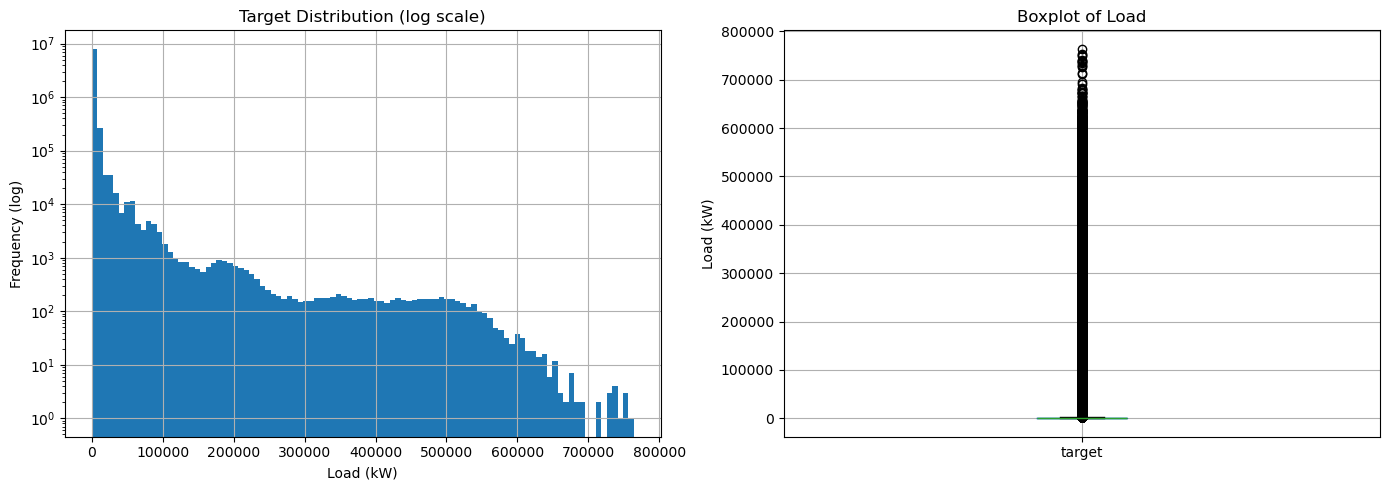


Outlier Statistics:
  Lower bound: -1478.00, Upper bound: 3106.00
  Number of outliers: 1082581 (12.82%)

--- Time Series Visualization (3 random clients) ---


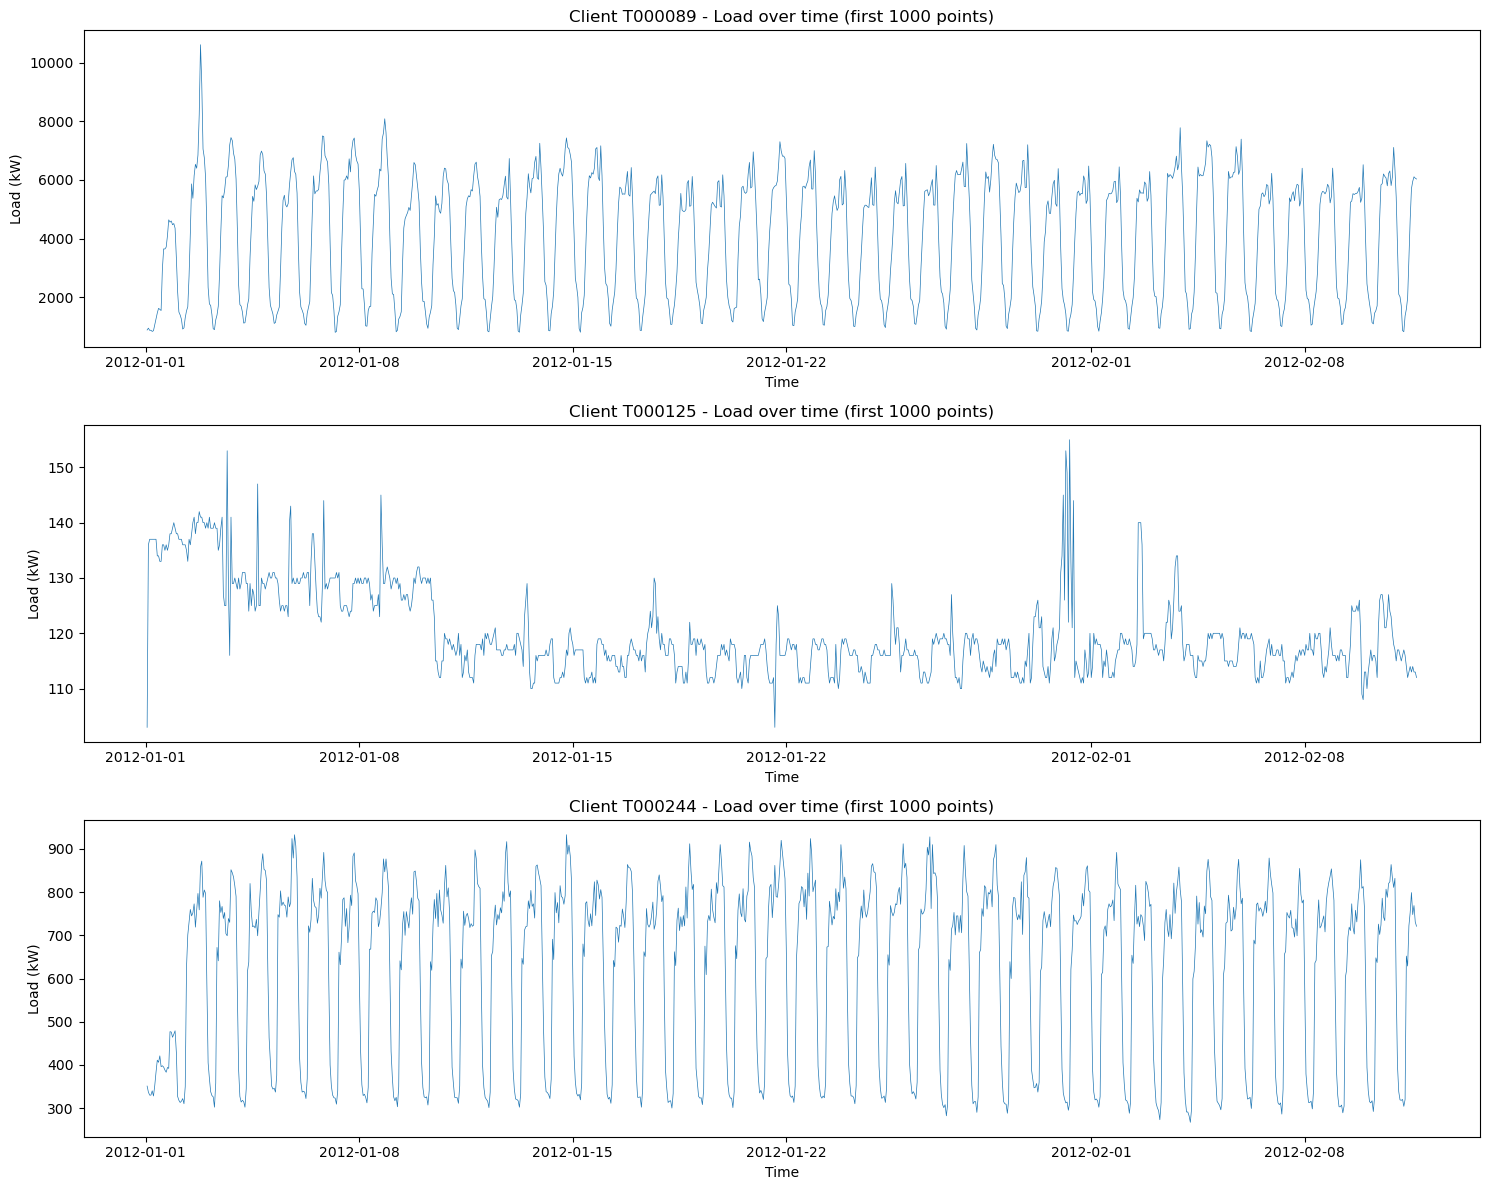


--- Seasonal Patterns ---


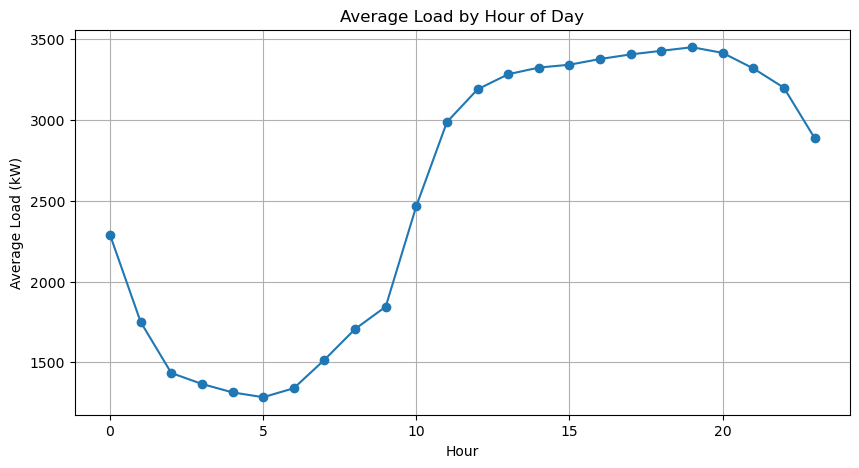

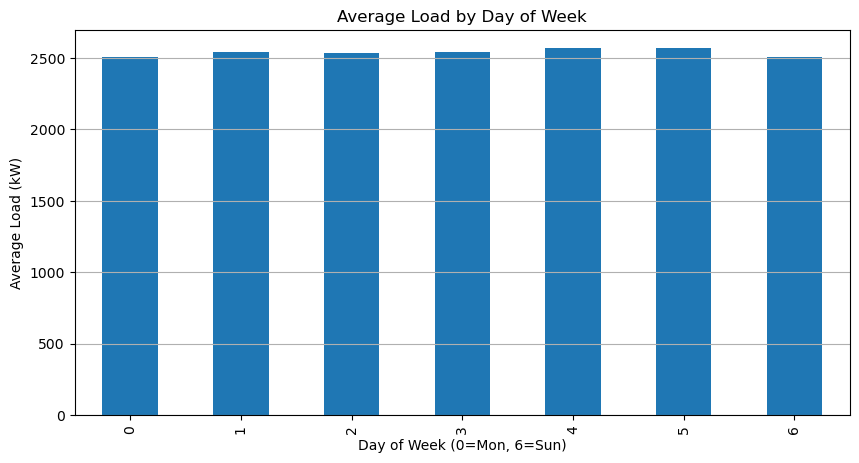

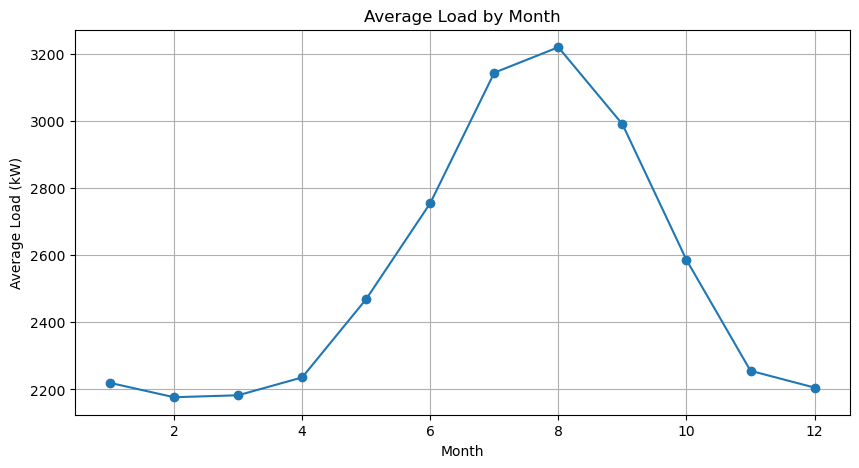

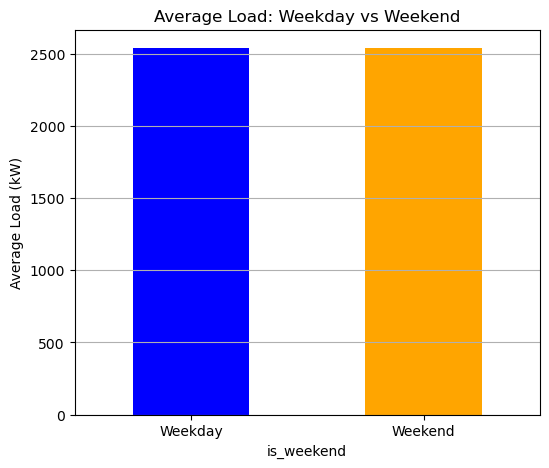

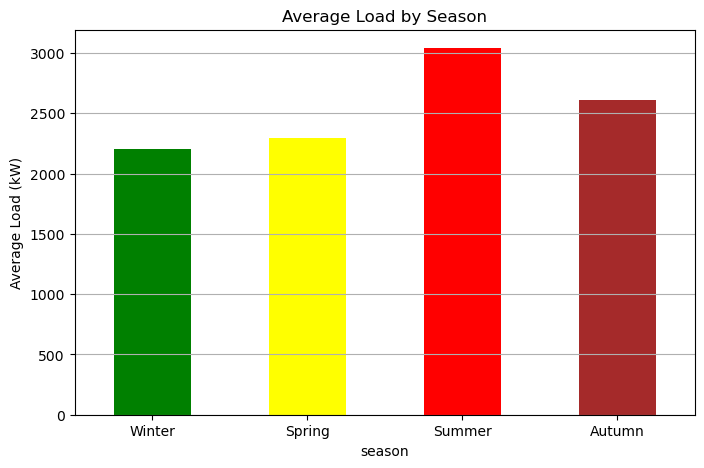


--- Feature Correlation Heatmap ---


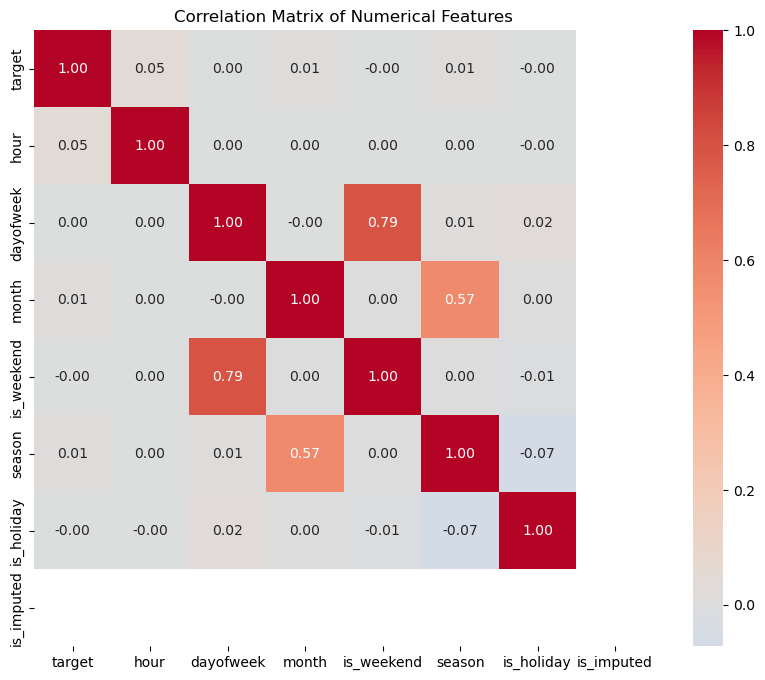

In [2]:
# Exploratory Data Analysis (EDA)
print("\n" + "="*50)
print("Starting Exploratory Data Analysis (EDA)")
print("="*50)


# Target variable distribution
print("\n--- Target Variable Distribution Analysis ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Histogram
df['target'].hist(bins=100, ax=axes[0], log=True)
axes[0].set_title('Target Distribution (log scale)')
axes[0].set_xlabel('Load (kW)')
axes[0].set_ylabel('Frequency (log)')
# Boxplot
df.boxplot(column='target', ax=axes[1])
axes[1].set_title('Boxplot of Load')
axes[1].set_ylabel('Load (kW)')
plt.tight_layout()
plt.show()

# Outlier detection using IQR method
Q1 = df['target'].quantile(0.25)
Q3 = df['target'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['target'] < lower_bound) | (df['target'] > upper_bound)]
print(f"\nOutlier Statistics:")
print(f"  Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"  Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# Time series plots for a few random clients
print("\n--- Time Series Visualization (3 random clients) ---")
sample_clients = np.random.choice(df['id'].unique(), size=min(3, df['id'].nunique()), replace=False)
fig, axes = plt.subplots(len(sample_clients), 1, figsize=(15, 4*len(sample_clients)))
if len(sample_clients) == 1:
    axes = [axes]
for ax, cid in zip(axes, sample_clients):
    client_data = df[df['id'] == cid].sort_values('timestamp')
    # Plot only first 1000 points to avoid clutter
    plot_data = client_data.head(1000)
    ax.plot(plot_data['timestamp'], plot_data['target'], linewidth=0.5)
    ax.set_title(f'Client {cid} - Load over time (first 1000 points)')
    ax.set_xlabel('Time')
    ax.set_ylabel('Load (kW)')
plt.tight_layout()
plt.show()

# Seasonal pattern analysis
print("\n--- Seasonal Patterns ---")

#  Average daily load curve (by hour)
hourly_avg = df.groupby('hour')['target'].mean()
plt.figure(figsize=(10,5))
hourly_avg.plot(marker='o')
plt.title('Average Load by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Load (kW)')
plt.grid(True)
plt.show()

# Weekly load pattern (by day of week)
dow_avg = df.groupby('dayofweek')['target'].mean()
plt.figure(figsize=(10,5))
dow_avg.plot(kind='bar')
plt.title('Average Load by Day of Week')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Average Load (kW)')
plt.grid(axis='y')
plt.show()

#  Monthly load pattern
month_avg = df.groupby('month')['target'].mean()
plt.figure(figsize=(10,5))
month_avg.plot(marker='o')
plt.title('Average Load by Month')
plt.xlabel('Month')
plt.ylabel('Average Load (kW)')
plt.grid(True)
plt.show()

# Weekend vs weekday
weekend_avg = df.groupby('is_weekend')['target'].mean()
plt.figure(figsize=(6,5))
weekend_avg.plot(kind='bar', color=['blue','orange'])
plt.xticks([0,1], ['Weekday', 'Weekend'], rotation=0)
plt.title('Average Load: Weekday vs Weekend')
plt.ylabel('Average Load (kW)')
plt.grid(axis='y')
plt.show()

# Seasonal load
season_avg = df.groupby('season')['target'].mean()
plt.figure(figsize=(8,5))
season_avg.plot(kind='bar', color=['green','yellow','red','brown'])
plt.xticks([0,1,2,3], ['Winter','Spring','Summer','Autumn'], rotation=0)
plt.title('Average Load by Season')
plt.ylabel('Average Load (kW)')
plt.grid(axis='y')
plt.show()

# Correlation analysis
print("\n--- Feature Correlation Heatmap ---")
# Select numerical features
numeric_cols = ['target', 'hour', 'dayofweek', 'month', 'is_weekend', 'season', 'is_holiday', 'is_imputed']
corr_df = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()



In [2]:
# Select customers for accelerated training
use_subset_clients = True
if use_subset_clients:
    # Obtain all unique customer IDs, sort them and then select 
    all_ids_sorted = sorted(df['id'].unique())
    selected_clients = all_ids_sorted[:20] 
    df = df[df['id'].isin(selected_clients)].reset_index(drop=True)
    print(f"Data shape: {df.shape}")

df = df.sort_values(['id', 'timestamp']).reset_index(drop=True)

train_ratio = 0.8
train_indices = []
test_indices = []

for client_id in df['id'].unique():
    client_mask = (df['id'] == client_id)
    client_data = df[client_mask]
    n = len(client_data)
    if n < 100:
        print(f"Warning: client {client_id} only have {n} data")
    split_idx = int(n * train_ratio)
    train_indices.extend(client_data.iloc[:split_idx].index.tolist())
    test_indices.extend(client_data.iloc[split_idx:].index.tolist())

train_df = df.loc[train_indices].copy()
test_df = df.loc[test_indices].copy()

print(f"Number of training samples: {len(train_df)}, Test sample size:{len(test_df)}")

Data shape: (526080, 10)
Number of training samples: 420860, Test sample size:105220


In [3]:
client_scalers = {}
for client_id in train_df['id'].unique():
    scaler = StandardScaler()
    client_train_target = train_df[train_df['id'] == client_id]['target'].values.reshape(-1, 1)
    scaler.fit(client_train_target)
    client_scalers[client_id] = scaler

def normalize_client(df, scalers):
    df = df.copy()
    normalized = []
    for client_id, group in df.groupby('id'):
        scaler = scalers[client_id]
        group = group.copy()
        group['target_norm'] = scaler.transform(group['target'].values.reshape(-1, 1)).flatten()
        normalized.append(group)
    return pd.concat(normalized).sort_index()

train_df = normalize_client(train_df, client_scalers)
test_df = normalize_client(test_df, client_scalers)

print("Statistics of the target_norm in the standardized training set:")
print(train_df['target_norm'].describe())

Statistics of the target_norm in the standardized training set:
count    4.208600e+05
mean     3.538701e-17
std      1.000001e+00
min     -4.337652e+00
25%     -6.672824e-01
50%     -2.020712e-01
75%      4.982205e-01
max      1.062666e+01
Name: target_norm, dtype: float64


In [4]:
# Construct a sliding window dataset
lookback = 24  
time_features = ['hour', 'dayofweek', 'month', 'is_weekend', 'season', 'is_holiday', 'is_imputed']

# Ensure that all time-related features are present in the test_df.
for col in time_features:
    if col not in test_df.columns:
        test_df[col] = 0  

all_client_ids = train_df['id'].unique().tolist()
client_to_idx = {cid: i for i, cid in enumerate(all_client_ids)}

class LoadDataset(Dataset):
    def __init__(self, df, lookback, time_features, client_to_idx):
        self.df = df
        self.lookback = lookback
        self.time_features = time_features
        self.client_to_idx = client_to_idx
        self.samples = []  # (client_id, position)

        for client_id, group in df.groupby('id'):
            group = group.reset_index(drop=True)
            n = len(group)
            if n > lookback:
                for pos in range(lookback, n):
                    self.samples.append((client_id, pos))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        client_id, pos = self.samples[idx]
        group = self.df[self.df['id'] == client_id].reset_index(drop=True)

        hist_load = group.loc[pos - self.lookback : pos - 1, 'target_norm'].values.astype(np.float32)
        curr_feat = group.loc[pos, self.time_features].values.astype(np.float32)
        target = group.loc[pos, 'target_norm'].astype(np.float32)
        client_idx = self.client_to_idx[client_id]

        return {
            'hist_load': torch.tensor(hist_load).unsqueeze(-1),  # [lookback, 1]
            'time_feat': torch.tensor(curr_feat),                # [num_time_features]
            'client_idx': torch.tensor(client_idx, dtype=torch.long),
            'target': torch.tensor(target)
        }

train_dataset = LoadDataset(train_df, lookback, time_features, client_to_idx)
test_dataset = LoadDataset(test_df, lookback, time_features, client_to_idx)

print(f"Number of training samples: {len(train_dataset)}, Number of test samples: {len(test_dataset)}")

Number of training samples: 420380, Number of test samples: 104740


In [5]:
# Define the LSTM model
class LSTMWithEmbedding(nn.Module):
    def __init__(self, num_clients, embedding_dim, lstm_hidden_size, lstm_num_layers,
                 time_feat_dim, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(num_clients, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            batch_first=True,
            dropout=dropout if lstm_num_layers > 1 else 0
        )
        total_feat_dim = lstm_hidden_size + embedding_dim + time_feat_dim
        self.fc = nn.Sequential(
            nn.Linear(total_feat_dim, 32), 
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, hist_load, time_feat, client_idx):
        client_emb = self.embedding(client_idx)
        lstm_out, (hidden, cell) = self.lstm(hist_load)
        last_hidden = hidden[-1]
        combined = torch.cat([last_hidden, client_emb, time_feat], dim=1)
        out = self.fc(combined).squeeze(-1)
        return out

# Model hyperparameters
embedding_dim = 4       
lstm_hidden_size = 32 
lstm_num_layers = 1       
time_feat_dim = len(time_features)
num_clients = len(all_client_ids)

model = LSTMWithEmbedding(num_clients, embedding_dim, lstm_hidden_size, lstm_num_layers, time_feat_dim).to(device)

In [6]:
batch_size = 64          
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                         num_workers=0, pin_memory=True)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)


In [7]:
from tqdm import tqdm 

epochs = 5
train_losses = []
test_losses = []

def train_epoch(model, loader, optimizer, criterion, epoch):  
    model.train()
    total_loss = 0
    # Wrap the data loader with the tqdm package and set the description
    pbar = tqdm(loader, desc=f'Train Epoch {epoch+1}/{epochs}', leave=False)
    for batch in pbar:
        hist_load = batch['hist_load'].to(device)
        time_feat = batch['time_feat'].to(device)
        client_idx = batch['client_idx'].to(device)
        target = batch['target'].to(device)

        optimizer.zero_grad()
        output = model(hist_load, time_feat, client_idx)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        batch_size = len(target)
        total_loss += loss.item() * batch_size
        # Display the current batch's loss on the right side of the progress bar.
        pbar.set_postfix({'batch_loss': f'{loss.item():.6f}'})
    pbar.close()
    return total_loss / len(loader.dataset)

def eval_epoch(model, loader, criterion, epoch):   
    model.eval()
    total_loss = 0
    pbar = tqdm(loader, desc=f'Val Epoch {epoch+1}/{epochs}', leave=False)
    with torch.no_grad():
        for batch in pbar:
            hist_load = batch['hist_load'].to(device)
            time_feat = batch['time_feat'].to(device)
            client_idx = batch['client_idx'].to(device)
            target = batch['target'].to(device)

            output = model(hist_load, time_feat, client_idx)
            loss = criterion(output, target)
            batch_size = len(target)
            total_loss += loss.item() * batch_size
            pbar.set_postfix({'batch_loss': f'{loss.item():.6f}'})
    pbar.close()
    return total_loss / len(loader.dataset)

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, epoch)
    test_loss = eval_epoch(model, test_loader, criterion, epoch)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    scheduler.step(test_loss)
    print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")

# Draw the loss curve 
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(test_losses, label='Test')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

Epoch  1/5 | Train Loss: 0.173619 | Test Loss: 0.117682


Epoch  2/5 | Train Loss: 0.145184 | Test Loss: 0.107141


Epoch  3/5 | Train Loss: 0.139785 | Test Loss: 0.103448


Train Epoch 4/5:  47%|██████████████████▉                     | 3107/6568 [27:20<30:15,  1.91it/s, batch_loss=0.066148]IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

Val Epoch 4/5:  90%|█████████████████████████████████████▊    | 1472/1637 [05:38<00:37,  4.37it/s, batch_loss=0.251366]IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

Train Epoch 5/5:  84%|█████████████████████████████████▌      | 5512/6568 [49:05<09:19,  1.89it/s, batch_loss=0.

In [8]:
# Test set evaluation
model.eval()
# Collect the predictions and actual values of each customer
client_preds_norm = {cid: [] for cid in all_client_ids}
client_targets_norm = {cid: [] for cid in all_client_ids}

with torch.no_grad():
    for batch in test_loader:
        hist_load = batch['hist_load'].to(device)
        time_feat = batch['time_feat'].to(device)
        client_idx = batch['client_idx'].to(device)
        target = batch['target'].to(device)
        output = model(hist_load, time_feat, client_idx)

        # Move to the CPU and convert to numpy
        client_ids_batch = [all_client_ids[idx] for idx in client_idx.cpu().numpy()]
        targets_batch = target.cpu().numpy()
        preds_batch = output.cpu().numpy()

        for i, cid in enumerate(client_ids_batch):
            client_preds_norm[cid].append(preds_batch[i])
            client_targets_norm[cid].append(targets_batch[i])

# Reverse standardization and calculate the indicators for each customer
client_metrics = {}
for cid in all_client_ids:
    if len(client_targets_norm[cid]) == 0:
        continue
    scaler = client_scalers[cid]
    y_true_norm = np.array(client_targets_norm[cid])
    y_pred_norm = np.array(client_preds_norm[cid])

    # Reverse standardization
    y_true = scaler.inverse_transform(y_true_norm.reshape(-1, 1)).flatten()
    y_pred = scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()

    # Calculation indicators
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100  
    r2 = r2_score(y_true, y_pred)

    client_metrics[cid] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

# Convert to DataFrame for easier statistics
metrics_df = pd.DataFrame(client_metrics).T
print("\nThe statistical data of each customer's indicators (in the original scale):")
print(metrics_df.describe())

# Summarized according to the customer reports
print("\n=== Cross-client indicator summary ===")
for metric in ['MAE', 'RMSE', 'MAPE', 'R2']:
    values = metrics_df[metric].dropna()
    print(f"{metric}:")
    print(f"  Mean value {values.mean():.4f}")
    print(f"  Median {values.median():.4f}")
    print(f"  Standard deviation {values.std():.4f}")
    if metric in ['MAE', 'RMSE', 'MAPE']:
        worst = values.nlargest(5)
        print(f"  The worst 5 clients（The biggest{metric}）:")
    else:
        worst = values.nsmallest(5)
        print(f"  The worst 5 clients（The smallest{metric}）:")
    for idx, val in worst.items():
        print(f"    Client {idx}: {val:.4f}")



The statistical data of each customer's indicators (in the original scale):
             MAE       RMSE          MAPE         R2
count  20.000000  20.000000  2.000000e+01  20.000000
mean   21.795719  30.101405  4.092196e+07   0.722342
std    19.706005  26.454822  1.261306e+08   0.698916
min     1.941090   2.558472  4.487235e+00  -2.239056
25%     8.140912  11.877134  6.413301e+00   0.837750
50%    13.410549  18.542883  7.845509e+00   0.897104
75%    32.800942  48.013104  1.111113e+01   0.907997
max    72.382744  97.761418  4.297204e+08   0.955787

=== Cross-client indicator summary ===
MAE:
  Mean value 21.7957
  Median 13.4105
  Standard deviation 19.7060
  The worst 5 clients（The biggestMAE）:
    Client T000015: 72.3827
    Client T000007: 58.6436
    Client T000005: 45.9809
    Client T000018: 36.4782
    Client T000003: 32.8304
RMSE:
  Mean value 30.1014
  Median 18.5429
  Standard deviation 26.4548
  The worst 5 clients（The biggestRMSE）:
    Client T000015: 97.7614
    Client T00


Performance metrics for client T000000:
  MAE: 4.8701 kW
  RMSE: 9.0653 kW
  MAPE: 388718720.00%
  R²: 0.8616

True load statistics (client T000000): mean=21.11 kW, std=24.37 kW
Predicted load statistics: mean=21.35 kW, std=21.75 kW


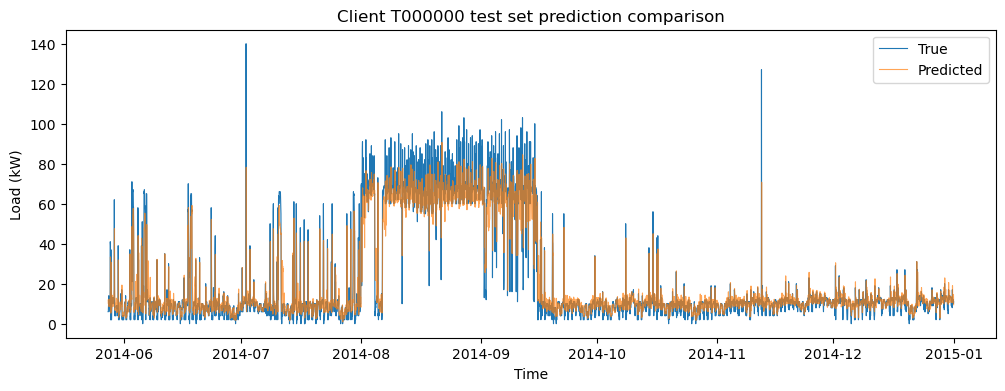

The model has been saved to lstm_electricity_forecast.pth


In [9]:
# Draw a prediction comparison chart for a certain client and output their indicators
sample_client = all_client_ids[0] if len(all_client_ids) > 0 else None
if sample_client is not None and sample_client in client_metrics:
    # Print out the performance indicators of this customer.
    if sample_client in metrics_df.index:
        print(f"\nPerformance metrics for client {sample_client}:")
        print(f"  MAE: {metrics_df.loc[sample_client, 'MAE']:.4f} kW")
        print(f"  RMSE: {metrics_df.loc[sample_client, 'RMSE']:.4f} kW")
        print(f"  MAPE: {metrics_df.loc[sample_client, 'MAPE']:.2f}%")
        print(f"  R²: {metrics_df.loc[sample_client, 'R2']:.4f}")
    
    scaler = client_scalers[sample_client]
    # Obtain the original load and the prediction of this customer in the test set
    client_test_df = test_df[test_df['id'] == sample_client].iloc[lookback:]  
    y_true_raw = client_test_df['target'].values
    y_pred_raw = scaler.inverse_transform(np.array(client_preds_norm[sample_client]).reshape(-1, 1)).flatten()

    # Make sure the length is consistent.
    min_len = min(len(y_true_raw), len(y_pred_raw))
    y_true_raw = y_true_raw[:min_len]
    y_pred_raw = y_pred_raw[:min_len]
    timestamps = client_test_df['timestamp'].iloc[:min_len]

    # A basic statistical comparison of the predicted values and the actual values for printing
    print(f"\nTrue load statistics (client {sample_client}): mean={y_true_raw.mean():.2f} kW, std={y_true_raw.std():.2f} kW")
    print(f"Predicted load statistics: mean={y_pred_raw.mean():.2f} kW, std={y_pred_raw.std():.2f} kW")

    plt.figure(figsize=(12, 4))
    plt.plot(timestamps, y_true_raw, label='True', linewidth=0.8)
    plt.plot(timestamps, y_pred_raw, label='Predicted', linewidth=0.8, alpha=0.7)
    plt.title(f'Client {sample_client} test set prediction comparison')
    plt.xlabel('Time')
    plt.ylabel('Load (kW)')
    plt.legend()
    plt.show()
    
torch.save(model.state_dict(), 'lstm_electricity_forecast.pth')
print("The model has been saved to lstm_electricity_forecast.pth")